In [2]:
#load and time based split
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/nakul/Desktop/PHYS/Equity-Signal-/data/ratio_with_returns.csv")
df["snapshot"] = pd.to_datetime(df["snapshot"])

years = sorted(df["snapshot"].dt.year.unique())
train_years = [y for y in years if y <= 2020]
val_years = [y for y in years if y in (2021, 2022)]
test_years = [y for y in years if y >= 2023]

train_df = df[df["snapshot"].dt.year.isin(train_years)].copy()
val_df = df[df["snapshot"].dt.year.isin(val_years)].copy()
test_df = df[df["snapshot"].dt.year.isin(test_years)].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 15164, Val: 4848, Test: 8319


In [3]:
#drop NaNs and build X y matrices
feature_cols = ["ROE", "ROA", "GrossMargin", "DebtToEquity", "AssetTurnover", "EPS"]
target_col = "excess_return"

train_df = train_df.dropna(subset=feature_cols + [target_col]).copy()
val_df = val_df.dropna(subset=feature_cols + [target_col]).copy()
test_df = test_df.dropna(subset=feature_cols + [target_col]).copy()

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Any NaNs? train={np.isnan(X_train).any()}, val={np.isnan(X_val).any()}, test={np.isnan(X_test).any()}")

Train: (9257, 6), Val: (2792, 6), Test: (4797, 6)
Any NaNs? train=False, val=False, test=False


In [4]:
#standardize and add import 
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_intercept(X_train_scaled)
X_val_b = add_intercept(X_val_scaled)
X_test_b = add_intercept(X_test_scaled)

feature_names = ["intercept"] + feature_cols
print("X_train_b shape:", X_train_b.shape)

X_train_b shape: (9257, 7)


In [6]:
# binary target and sigmoid 

z_train = (train_df[target_col]>0).astype(int).values
z_val = (val_df[target_col]>0).astype(int).values
z_test = (test_df[target_col]>0).astype(int).values

print("Class balance (fraction beating market):")
print(f"Train: {z_train.mean():.4f} ({z_train.sum()} of {len(z_train)})")
print(f"Val:   {z_val.mean():.4f} ({z_val.sum()} of {len(z_val)})")
print(f"Test:  {z_test.mean():.4f} ({z_test.sum()} of {len(z_test)})")

def sigmoid(z):
    z_clipped = np.clip(z,-500,500)
    return 1 / (1 + np.exp(-z_clipped))

test_inputs = np.array([-10, -1, 0, 1, 10])
print("\nSigmoid sanity check:")
for val in test_inputs:
    print(f"  sigmoid({val}) = {sigmoid(val):.6f}")


Class balance (fraction beating market):
Train: 0.4605 (4263 of 9257)
Val:   0.4180 (1167 of 2792)
Test:  0.3204 (1537 of 4797)

Sigmoid sanity check:
  sigmoid(-10) = 0.000045
  sigmoid(-1) = 0.268941
  sigmoid(0) = 0.500000
  sigmoid(1) = 0.731059
  sigmoid(10) = 0.999955


In [7]:
def log_loss(X, z, theta):
    """
    Binary cross entropy loss.
    """
    p_hat = sigmoid(X @ theta)
    eps = 1e-15
    p_hat = np.clip(p_hat, eps, 1- eps)
    
    return -np.mean(z * np.log(p_hat) + (1-z) * np.log(1-p_hat))

def logistic_gradient_descent(X,z, learning_rate=0.1, n_iterations=1000):
    """ 
    Same structure as linear regressions gradient descent but predictions go 
    through the signoid function.
    """
    
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    loss_history = []

    for i in range(n_iterations):
        p_hat = sigmoid( X @ theta)
        errors = p_hat - z 
        gradient = (1 / n_samples) * (X.T @ errors)
        theta = theta -  (learning_rate * gradient )

        loss_history.append(log_loss(X,z,theta))

    return theta, loss_history


theta_log, log_loss_history = logistic_gradient_descent(X_train_b, z_train, learning_rate=0.1, n_iterations=2000)

print("Initial log-loss:", log_loss_history[0])
print("Final log-loss:  ", log_loss_history[-1])

print("\nLearned parameters:")
for name, val in zip(feature_names, theta_log):
    print(f"  {name}: {val:.6f}")

val_loss = log_loss(X_val_b, z_val, theta_log)
print(f"\nValidation log-loss: {val_loss:.6f}")


Initial log-loss: 0.6927647908224003
Final log-loss:   0.6863302905479635

Learned parameters:
  intercept: -0.160169
  ROE: 0.005169
  ROA: 0.130920
  GrossMargin: 0.115736
  DebtToEquity: 0.036124
  AssetTurnover: 0.039635
  EPS: -0.041199

Validation log-loss: 0.682579


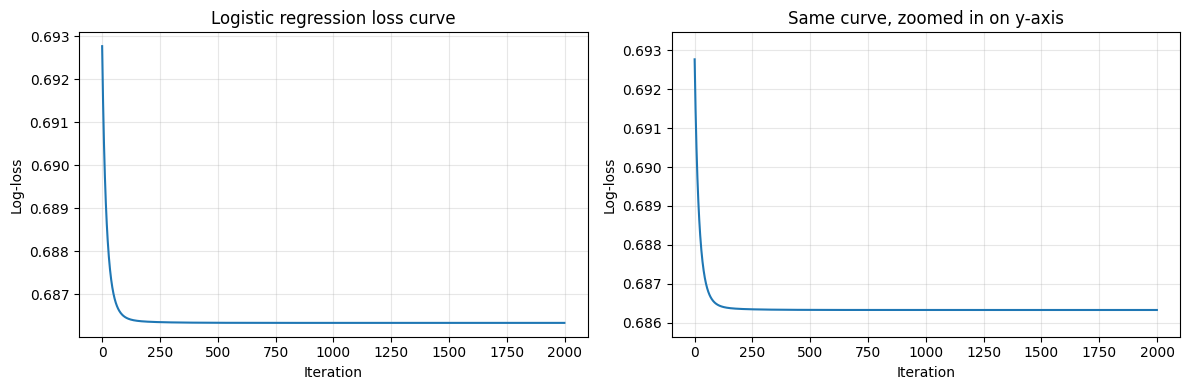

Initial loss: 0.692765
Final loss:   0.686330

Gradient norm at final theta: 0.0000010688


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log_loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log-loss")
axes[0].set_title("Logistic regression loss curve")
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_loss_history)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Log-loss")
axes[1].set_title("Same curve, zoomed in on y-axis")
axes[1].set_ylim(min(log_loss_history) * 0.999, max(log_loss_history) * 1.001)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {log_loss_history[0]:.6f}")
print(f"Final loss:   {log_loss_history[-1]:.6f}")

# Gradient norm at the final theta - same convergence check as linear regression
p_hat_final = sigmoid(X_train_b @ theta_log)
errors_final = p_hat_final - z_train
gradient_final = (1 / X_train_b.shape[0]) * (X_train_b.T @ errors_final)
print(f"\nGradient norm at final theta: {np.linalg.norm(gradient_final):.10f}")

In [9]:
def accuracy(X, z, theta, threshold=0.5):
    p_hat = sigmoid(X @ theta)
    z_pred = (p_hat >= threshold).astype(int)
    return np.mean(z_pred == z)

def majority_baseline_accuracy(z_train, z_eval):
    majority_class = int(z_train.mean()>= 0.5)
    return np.mean(z_eval == majority_class)

train_acc = accuracy(X_train_b, z_train, theta_log)
val_acc = accuracy(X_val_b, z_val, theta_log)

train_baseline = majority_baseline_accuracy(z_train, z_train)
val_baseline = majority_baseline_accuracy(z_train, z_val)


print(f"Train accuracy:          {train_acc:.4f}")
print(f"Train majority baseline: {train_baseline:.4f}")
print(f"Train improvement:       {(train_acc - train_baseline)*100:+.2f} percentage points")

print(f"\nVal accuracy:            {val_acc:.4f}")
print(f"Val majority baseline:   {val_baseline:.4f}")
print(f"Val improvement:         {(val_acc - val_baseline)*100:+.2f} percentage points")

Train accuracy:          0.5394
Train majority baseline: 0.5395
Train improvement:       -0.01 percentage points

Val accuracy:            0.5555
Val majority baseline:   0.5820
Val improvement:         -2.65 percentage points


In [11]:
print("=" * 50)
print("LOGISTIC REGRESSION - TEST SET")
print("=" * 50)

test_acc = accuracy(X_test_b, z_test, theta_log)
test_baseline = majority_baseline_accuracy(z_train, z_test)

print(f"Test accuracy:          {test_acc:.4f}")
print(f"Test majority baseline: {test_baseline:.4f}")
print(f"Test improvement:       {(test_acc - test_baseline)*100:+.2f} percentage points")

LOGISTIC REGRESSION - TEST SET
Test accuracy:          0.6319
Test majority baseline: 0.6796
Test improvement:       -4.77 percentage points
